## **Authors**

*The work can be done in groups of up to 3 students. Please complete the following fields with your group number and list your names along with ISU ID numbers.*

> **Technical Vision**
>
> 1. Кормушкина Ксения, 466278
> 2. Носуленко Егор, 466921

*The task and guidelines were prepared by Andrei Zhdanov and Sergei Shavetov, ITMO University, 2025.*

# **Practical Assignment No 6. Images Morphological Analysis**
# **Практическое задание № 6. Морфологический анализ изображений**

*Studying of the digital images morphological analysis main principles.*

*Изучение основных принципов морфологического анализа цифровых изображений.*

## **Task 1. Basic morphological operations**

*Select an arbitrary image containing shape defects (internal "holes" and external  "ledges"). Using basic morphological operations, completely remove or minimize defects.*

## **Задание 1. Базовые морфологические операции**

*Выберите произвольное изображение, содержащее дефекты формы (внутренние «дыры» и внешние «выступы»). С помощью базовых морфологических операций полностью устраните или минимизируйте дефекты.*

The term *morphology* literally translates as "the science of form" from Greek. Morphological analysis is used in many areas of knowledge, including image processing. It is a relatively universal approach, therefore it stands apart from all previously considered methods. Using mathematical morphology in image processing, it is possible to filter noise, segment objects, detect edges, implement a search for a given object in an image, calculate the image "skeleton", etc. Let's consider the image binary morphology basic operations $A$ by the structural element $B$:

 - Dilation (expansion): $C = A \oplus B$ dilates binary image $A$ by structural element $B$;
 - Erosion: $C = A \ominus B$ narrows down the binary image $A$ by structural element $B$;
 - Open: $C = (A \ominus B) \oplus B$ removes binary image external defects $A$ by structural element $B$;
 - Close: $C = (A \oplus B) \ominus B$ removes binary image internal defects $A$ by structural element $B$.

$\oplus$ and $\ominus$ operations which were used above are addition and subtraction of Minkowski, respectively.

| ![Morphological operations](images/morphology.png "The result of binary morphological operations") | 
|:--:| 
| *The result of binary morphological operations: a) binary image $A$, b) disk-shape structural element $B$, c) dilation, d) erosion, e) open, f) close.
*Результат бинарных морфологических операций: a) бинарное изображение $A$, b) структурный элемент в форме диска $B$, c) дилатация, d) эрозия, e) размыкание, f) замыкание.* |

Термин *морфология* дословно переводится с греческого как «наука о форме». Морфологический анализ используется во многих областях знаний, включая обработку изображений. Это относительно универсальный подход, поэтому он стоит особняком среди всех ранее рассмотренных методов. С помощью математической морфологии при обработке изображений можно фильтровать шумы, сегментировать объекты, выделять границы, реализовывать поиск заданного объекта на изображении, вычислять «скелет» изображения и т.д. Рассмотрим базовые операции бинарной морфологии изображения $A$ по структурному элементу $B$:

- Дилатация (расширение): $C = A \oplus B$ расширяет бинарное изображение $A$ с помощью структурного элемента $B$;
- Эрозия (сужение): $C = A \ominus B$ сужает бинарное изображение $A$ с помощью структурного элемента $B$;
- Размыкание (открытие): $C = (A \ominus B) \oplus B$ удаляет внешние дефекты бинарного изображения $A$ с помощью структурного элемента $B$;
- Замыкание (закрытие): $C = (A \oplus B) \ominus B$ удаляет внутренние дефекты бинарного изображения $A$ с помощью структурного элемента $B$.

Операции $\oplus$ и $\ominus$, которые были использованы выше, — это сложение и вычитание Минковского соответственно.


**Morphological operations with OpenCV**

OpenCV provies following general functions to work with morphological operations:
 - `cv2.getStructuringElement(shape, size, anchor)` - define a structural element with given $shape$ and $size$. The morphologial element is defined with a binary matrix indicating the pixels which are affected by mask in relationship to the anchor point. If the $anchor$ point is not defined then it is placed at the center of kernel. The following default structuring elements are supported:
  - `cv2.MORPH_RECT` - a rectangular structuring element with given $size$;
  - `cv2.MORPH_CROSS` - a cross-shaped structuring element with given $size$;
  - `cv2.MORPH_ELLIPSE` - an elliptic structuring element inscribed into a rectangle with given $size$.
 - `cv::morphologyEx(A, op, B, anchor, iters, borderType, borderValue)` - apply a morphological filtering operation $op$ to an image $A$ with structural element $B$ $iters$ times. If the number of iterations is not defined, then it is defaulted to $1$. It also allows redefining the $anchor$ point value and function behavior near borders. In Python language the resulting image $C$ is a return value of a function. The possible morphological operations are:
  - `cv2.MORPH_ERODE` - perform the morphological erosion operation $C = A \ominus B$. `cv2.erode()` function can be used to do the same operation;
  - `cv2.MORPH_DILATE` - perform the morphological dilation operation $C = A \oplus B$. `cv2.dilate()` function can be used to do the same operation;
  - `cv2.MORPH_OPEN` - perform the morphological opening operation $C = (A \ominus B) \oplus B$. $open(A, B) = dilate(erode(A, B), B)$;
  - `cv2.MORPH_CLOSE` - perform the morphological closing operation $C = (A \oplus B) \ominus B$. $close(A, B) = erode(dilate(A, B), B)$.
  - `cv2.MORPH_GRADIENT` - perform the morphological gradient operation. This is the difference between dilation and erosion.  $gradient(A, B) = dilate(A, B)  - erode(A, B)$;
  - `cv2.MORPH_TOPHAT` - perform the morphological "top hat" operation. This is the difference between image and its opening. $tophat(A, B) = A - open(A, B)$;
  - `cv2.MORPH_BLACKHAT` - perform the morphological "black hat" operation. This is the difference between image closing and an image. $blackhat(A, B) = close(A, B)  - A$;
  - `cv2.MORPH_HITMISS` - perform the opening "hit \& miss" operation.

There are several more functions which are useful when working with morphology:
 - `retval, labels = cv2.connectedComponents(A)` function is used to list all connected components of the image $A$. It returns a tuple with the number of connected components and a matrix of component $labels$. Every image pixel is labeled with corresponding label and stored in the $labels$ matrix.
 - `retval, labels, stats, centroids = cv2.connectedComponentsWithStats(A)` function is similar with the above `connectedComponents()` one, but it also computes the statistics for each of the components. It returns a tuple with the number of connected components and a matrix with component $labels$, $stats$ and $centroids$. Statistics ($stats$) is a 2-dimensional matrix with first dimension being a component id ($label$) and the second dimension being a statistic id. Type of this matrix is 32 bit signed integer ($int32$). Component $centroids$ is a 2-dimensional matrix with first dimension being a component id ($label$) and the second dimension being $0$ for $X$, and $1$ for $Y$. Statistics include the following data:
  - `cv2.CC_STAT_LEFT` - the leftmost ($X$) coordinate of a component;
  - `cv2.CC_STAT_TOP` - the topmost ($Y$) coordinate of a component;
  - `cv2.CC_STAT_WIDTH` - the horizontal size ($width$) of a component;
  - `cv2.CC_STAT_HEIGHT` - the vertical size ($height$) of a component;
  - `cv2.CC_STAT_AREA` - the component size (in pixels).

**Морфологические операции в OpenCV**

OpenCV предоставляет следующие общие функции для работы с морфологическими операциями:
- `cv2.getStructuringElement(shape, size, anchor)` — определяет структурный элемент с заданными $shape$ и $size$. Морфологический элемент определяется бинарной матрицей, указывающей, какие пиксели затронуты маской относительно точки привязки. Если точка $anchor$ не задана, то она помещается в центр ядра. Поддерживаются следующие структурные элементы по умолчанию:
  - `cv2.MORPH_RECT` — прямоугольный структурный элемент заданного $size$;
  - `cv2.MORPH_CROSS` — крестообразный структурный элемент заданного $size$;
  - `cv2.MORPH_ELLIPSE` — эллиптический структурный элемент, вписанный в прямоугольник заданного $size$.
- `cv::morphologyEx(A, op, B, anchor, iters, borderType, borderValue)` — применяет операцию морфологической фильтрации $op$ к изображению $A$ со структурным элементом $B$ $iters$ раз. Если количество итераций не задано, по умолчанию используется $1$. Также позволяет переопределять значение точки $anchor$ и поведение функции у границ. В языке Python результирующее изображение $C$ является возвращаемым значением функции. Доступны следующие морфологические операции:
  - `cv2.MORPH_ERODE` — выполняет операцию морфологической эрозии $C = A \ominus B$. Для выполнения той же операции можно использовать функцию `cv2.erode()`;
  - `cv2.MORPH_DILATE` — выполняет операцию морфологической дилатации $C = A \oplus B$. Для выполнения той же операции можно использовать функцию `cv2.dilate()`;
  - `cv2.MORPH_OPEN` — выполняет операцию морфологического размыкания $C = (A \ominus B) \oplus B$. $open(A, B) = dilate(erode(A, B), B)$;
  - `cv2.MORPH_CLOSE` — выполняет операцию морфологического замыкания $C = (A \oplus B) \ominus B$. $close(A, B) = erode(dilate(A, B), B)$;
  - `cv2.MORPH_GRADIENT` — выполняет операцию морфологического градиента. Это разность между дилатацией и эрозией. $gradient(A, B) = dilate(A, B) - erode(A, B)$;
  - `cv2.MORPH_TOPHAT` — выполняет операцию «верхняя шляпа» (top hat). Это разность между изображением и его размыканием. $tophat(A, B) = A - open(A, B)$;
  - `cv2.MORPH_BLACKHAT` — выполняет операцию «черная шляпа» (black hat). Это разность между замыканием изображения и самим изображением. $blackhat(A, B) = close(A, B) - A$;
  - `cv2.MORPH_HITMISS` — выполняет операцию «hit & miss» (попадание/промах).

Существует еще несколько функций, полезных при работе с морфологией:
- `retval, labels = cv2.connectedComponents(A)` — функция используется для перечисления всех связных компонент изображения $A$. Возвращает кортеж с количеством связных компонент и матрицу $labels$ (меток). Каждый пиксель изображения получает соответствующую метку, которая сохраняется в матрице $labels$.
- `retval, labels, stats, centroids = cv2.connectedComponentsWithStats(A)` — эта функция аналогична `connectedComponents()`, но также вычисляет статистику для каждой компоненты. Возвращает кортеж с количеством связных компонент, а также матрицы $labels$, $stats$ и $centroids$. Статистика ($stats$) — это двумерная матрица, где первое измерение — это идентификатор компоненты ($label$), а второе — идентификатор статистического показателя. Тип этой матрицы — 32-битное целое число со знаком ($int32$). Центроиды компонент ($centroids$) — это двумерная матрица, где первое измерение — идентификатор компоненты ($label$), а второе: $0$ для координаты $X$ и $1$ для координаты $Y$. Статистика включает следующие данные:
  - `cv2.CC_STAT_LEFT` — самая левая координата $X$ компоненты;
  - `cv2.CC_STAT_TOP` — самая верхняя координата $Y$ компоненты;
  - `cv2.CC_STAT_WIDTH` — горизонтальный размер ($width$) компоненты;
  - `cv2.CC_STAT_HEIGHT` — вертикальный размер ($height$) компоненты;
  - `cv2.CC_STAT_AREA` — размер компоненты (в пикселях).

One of examples of using the morphological operations is edge detection. Morphological operations allows us calculating the inner and outer shape, dedending on which operation is used:

 - $C=A-(A\ominus B)$ - the inner edge is the difference between the image and its erosion result
 - $C=(A\oplus B)-A$ - the outer edge is the difference between the image dilations and itself.

 Одним из примеров использования морфологических операций является обнаружение границ. Морфологические операции позволяют нам вычислять внутреннюю и внешнюю границу формы в зависимости от того, какая операция используется:

- $C = A - (A \ominus B)$ — внутренняя граница — это разность между изображением и результатом его эрозии;
- $C = (A \oplus B) - A$ — внешняя граница — это разность между дилатацией изображения и самим изображением.

Now when we learned what the morphological operations are, let's try them in action.

Теперь, когда мы узнали, что такое морфологические операции, давайте попробуем их в действии.

### **1.1 Preparation**

First, we need to add some imports for OpenCV to work correctly.

### **1.1 Подготовка**

Сначала нам нужно добавить несколько импортов для корректной работы OpenCV.

In [24]:
# Import OpenCV library both as cv and cv2
import cv2
import cv2 as cv
# Import NumPy library both as np and numpy
import numpy
import numpy as np

Also we will import `ShowImages()` function from the first practical assignment to use it here. It is placed in `pa_utils`.

Также мы импортируем функцию `ShowImages()` из первого практического задания, чтобы использовать её здесь. Она находится в модуле `pa_utils`.

In [25]:
from pa_utils import ShowImages

### **1.2 Read and display an image**

Now let's open our image which we will use in the current task. Since the image is a binary image, we will open it in grayscale. We will use previously introduced functions for image display. The binary image we are going to use is in fact the grayscale image, however it has only two types of pixels: black pixels with values $0$ and white pixels with value $255$. White pixels define the shape pixels and black ones are background. Such image can be created from a grayscale image by thresholding it with `cv2.threshold()` function. In our case the source image is already in $\{0, 255\}$ values set, however its shape is defined by black pixels, so we will threshold it to invert and make sure that only $0$ or $255$ values remain.

### **1.2 Чтение и отображение изображения**

Теперь откроем изображение, которое будем использовать в текущем задании. Поскольку изображение бинарное, мы откроем его в градациях серого. Для отображения изображения будем использовать ранее представленные функции. Бинарное изображение, которое мы собираемся использовать, на самом деле является полутоновым, однако оно содержит только два типа пикселей: черные пиксели со значением $0$ и белые пиксели со значением $255$. Белые пиксели определяют пиксели формы, а черные — фон. Такое изображение можно создать из полутонового изображения с помощью пороговой обработки функцией `cv2.threshold()`. В нашем случае исходное изображение уже имеет множество значений $\{0, 255\}$, однако его форма определяется черными пикселями, поэтому мы применим пороговую обработку для инвертирования, чтобы убедиться, что остаются только значения $0$ или $255$.

In [ ]:
# Read a binary image from file in grayscale
fn1 = "images/star.png"
I1 = cv.imread(fn1, cv.IMREAD_GRAYSCALE)
if not isinstance(I1, np.ndarray) or I1.data == None:
  print("Error reading file \"{}\"".format(fn1))
else:
  # Threshold it
  ret, I1 = cv.threshold(I1, 127, 255, cv.THRESH_BINARY_INV)
  # Display it
  ShowImages([("Source image", I1)])

### **1.3 Morphological operations**

Before trying to clean up an image, we will try running considered morphological operations on it.

### **1.3 Морфологические операции**

Прежде чем пытаться очистить изображение, мы попробуем применить к нему рассмотренные морфологические операции.

#### **1.3.1 Structuring element**

The first thing we need to to is create a structuring element. Let's create different default types of elements and display them to have a look.

#### **1.3.1 Структурный элемент**

Первое, что нам нужно сделать — это создать структурный элемент. Давайте создадим различные стандартные типы элементов и отобразим их, чтобы посмотреть.

In [ ]:
# Create an 11 x 11 pixels elliptical structuring element (filled circle)
ellipse_element = cv.getStructuringElement(cv.MORPH_ELLIPSE, (11, 11))
# Create an 11 x 11 pixels rectangular structuring element
rect_element = cv.getStructuringElement(cv.MORPH_RECT, (11, 11))
# Create an 11 x 11 pixels cross shape structuring element
cross_element = cv.getStructuringElement(cv.MORPH_CROSS, (11, 11))

# And display them
ShowImages([("Ellipse", ellipse_element), 
            ("Rect", rect_element), 
            ("Cross", cross_element)], 3, vmin = 0, vmax = 1)

# Let's also print one of them to see the contents
print("ellipse_element = ")
print(ellipse_element)

As you see, the structuring element is a binary matrix with `1` meaning that this pixel is used in morphological operations and `0` meaning that pixel is omitted. So, this is very similar to kernels which were used during 2D filters and we can create own elements if needed.

Как вы видите, структурный элемент — это бинарная матрица, где `1` означает, что данный пиксель используется в морфологических операциях, а `0` — что пиксель игнорируется. Таким образом, это очень похоже на ядра, которые использовались при двумерной фильтрации, и при необходимости мы можем создавать собственные элементы.

During this assignment we will use the elliptical structuring element, however you may try using the different one and compare the results.

В ходе этого задания мы будем использовать эллиптический структурный элемент, однако вы можете попробовать использовать другой элемент и сравнить результаты.

In [ ]:
# Shorten the element name
element = ellipse_element

#### **1.3.2 Erode operation**

The first operation we will try is an erode operation. It erodes the binary image narrowing the shape. Let's run it several times and check how it affect the object morphology.

#### **1.3.2 Операция эрозии**

Первая операция, которую мы попробуем — это операция эрозии. Она сужает бинарное изображение, уменьшая форму. Давайте выполним её несколько раз и посмотрим, как это влияет на морфологию объекта.

In [ ]:
# Try the erode operation
I1erode1 = cv.morphologyEx(I1, cv.MORPH_ERODE, element, iterations = 1)
I1erode2 = cv.morphologyEx(I1, cv.MORPH_ERODE, element, iterations = 2)
I1erode3 = cv.morphologyEx(I1, cv.MORPH_ERODE, element, iterations = 3)
ShowImages([("Source", I1),
            ("Erode 1 iteration", I1erode1),
            ("Erode 2 iterations", I1erode2),
            ("Erode 3 iterations", I1erode3)], 2)

As you can see, eroding a morphology decreases it's side and completely removes small external areas, however internal holes got bigger.

Как вы можете видеть, эрозия морфологии уменьшает её размеры и полностью удаляет небольшие внешние области, однако внутренние отверстия становятся больше.

#### **1.3.3 Dilation operation**

Opposite to erosion, dilation operation grows and object. Let's run it several times and check how it affect the object morphology.

#### **1.3.3 Операция дилатации**

В отличие от эрозии, операция дилатации расширяет объект. Давайте выполним её несколько раз и посмотрим, как это влияет на морфологию объекта.

In [ ]:
# Try the dilate operation
Idilate1 = cv.morphologyEx(I1, cv.MORPH_DILATE, element, iterations = 1)
Idilate2 = cv.morphologyEx(I1, cv.MORPH_DILATE, element, iterations = 2)
Idilate3 = cv.morphologyEx(I1, cv.MORPH_DILATE, element, iterations = 3)
ShowImages([("Source", I1),
            ("Dilate 1 iteration", Idilate1),
            ("Dilate 2 iterations", Idilate2),
            ("Dilate 3 iterations", Idilate3)], 2)

As you can see, now all internal holes are filled, the object increased its size, however all outside noise also got much more noticeable.

Как вы можете видеть, теперь все внутренние отверстия заполнены, объект увеличился в размере, однако все внешние шумы также стали гораздо более заметными.

#### **1.3.4 Open operation**

The open operation is a dilation of an erosion of the object morphology. It should allow removing the external object morphology defects while keeping the general shape and shape size almost untouched. Let's run it several times and check how it affect the object morphology.

#### **1.3.4 Операция размыкания (open)**

Операция размыкания представляет собой дилатацию эрозии морфологии объекта. Она должна позволять удалять внешние дефекты морфологии объекта, сохраняя общую форму и размер почти неизменными. Давайте выполним её несколько раз и посмотрим, как это влияет на морфологию объекта.

In [ ]:
# Try the open operation
I1open1 = cv.morphologyEx(I1, cv.MORPH_OPEN, element, iterations = 1)
I1open2 = cv.morphologyEx(I1, cv.MORPH_OPEN, element, iterations = 2)
I1open3 = cv.morphologyEx(I1, cv.MORPH_OPEN, element, iterations = 3)
ShowImages([("Source", I1),
            ("Open 1 iteration", I1open1),
            ("Open 2 iterations", I1open2),
            ("Open 3 iterations", I1open3)], 2)

You can see that now most of the external defects are removed while internal ones are more or less as they were before.

Вы можете видеть, что теперь большинство внешних дефектов удалены, в то время как внутренние остались более или менее такими же, как и раньше.

#### **1.3.5 Close operation**

The close operation is an erosion of a dilation of the object morphology. It should allow removing the internal object morphology defects while keeping the general shape and shape size almost untouched. Let's run it several times and check how it affect the object morphology.

#### **1.3.5 Операция замыкания (close)**

Операция замыкания представляет собой эрозию дилатации морфологии объекта. Она должна позволять удалять внутренние дефекты морфологии объекта, сохраняя общую форму и размер почти неизменными. Давайте выполним её несколько раз и посмотрим, как это влияет на морфологию объекта.

In [ ]:
# Try the close operation
I1close1 = cv.morphologyEx(I1, cv.MORPH_CLOSE, element, iterations = 1)
I1close2 = cv.morphologyEx(I1, cv.MORPH_CLOSE, element, iterations = 2)
I1close3 = cv.morphologyEx(I1, cv.MORPH_CLOSE, element, iterations = 3)
ShowImages([("Source", I1),
            ("Close 1 iteration", I1close1),
            ("Close 2 iterations", I1close2),
            ("Close 3 iterations", I1close3)], 2)

You can see that now most of internal defects are removed while the external ones are more or less as they were before.

Вы можете видеть, что теперь большинство внутренних дефектов удалены, в то время как внешние остались более или менее такими же, как и раньше.

#### **1.3.6 Contours**

With morphology it's easy to extract the object contours. We can get either internal or external contour of an object:
 - To get an internal contour of an object, we have to subtract the object erosion result from the object itself;
 - To get an external contour of an object, we have to subtract the object from its dilation result.

 The width of the contour is defined by the structuring element. To check these methods, we will create a smaller structuring element with size $3 \times 3$.

 #### **1.3.6 Контуры**

С помощью морфологии легко выделить контуры объекта. Мы можем получить как внутренний, так и внешний контур объекта:
- Чтобы получить внутренний контур объекта, нужно вычесть результат эрозии объекта из самого объекта;
- Чтобы получить внешний контур объекта, нужно вычесть объект из результата его дилатации.

Ширина контура определяется структурным элементом. Чтобы проверить эти методы, мы создадим структурный элемент меньшего размера $3 \times 3$.

In [ ]:
# Create a 3 x 3 elliptical structuring element
element3x3 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
I1internal = I1 - cv.morphologyEx(I1, cv.MORPH_ERODE, element, iterations = 1)
I1external = cv.morphologyEx(I1, cv.MORPH_DILATE, element, iterations = 1) - I1
ShowImages([("Source", I1), 
            ("Internal contour", I1internal), 
            ("External contour", I1external)], 2)

#### **1.3.7 "bwareaopen" from MATLAB operation**

MATLAB provides a very useful operation named `bwareaopen()` which works with morphology, however OpenCV doesn't have it. This operation searches for all areas of size less than the given one and opens them. This operation is very handy when working with morphology as it allows to remove all small areas from morphology, so let's implement. Let's implement it.

The implementation is very similar and straightforward:
1. Use the `cv2.connectedComponentsWithStats()` function to search for all connected components of the image with given connectivity.
2. Loop through components and fill the areas with size less than given.

#### **1.3.7 Операция `bwareaopen` из MATLAB**

MATLAB предоставляет очень полезную операцию под названием `bwareaopen()`, которая работает с морфологией, однако в OpenCV её нет. Эта операция ищет все области размером меньше заданного и удаляет их. Данная операция очень удобна при работе с морфологией, так как позволяет удалить все мелкие области, поэтому давайте реализуем её.

Реализация очень проста и понятна:
1. Используйте функцию `cv2.connectedComponentsWithStats()` для поиска всех связных компонент изображения с заданной связностью.
2. Переберите компоненты и залейте области, размер которых меньше заданного.

In [26]:
# Remove small objects from binary image
# @param[in] I Image
# @param[in] dim A minium size of an area to keep
# @param[int] connectivity Pixel connectivity
# @return An image with components less then dim in size removed
def bwareaopen(I : np.ndarray, dim : int, connectivity : int = 8):
  # We work with single layer images only
  if I.ndim > 2:
    return None
  Iout = I.copy()

  # Find all connected components
  num_labels, labels, stats, centroids = cv.connectedComponentsWithStats(Iout, connectivity = connectivity)

  # Check size of all connected components
  for i in range(num_labels):
    # Remove connected components smaller than dim
    if stats[i, cv.CC_STAT_AREA] < dim:
      Iout[labels == i] = 0

  return Iout

Try running it with our source image and open all areas with size less than $30$.

Попробуйте запустить её на нашем исходном изображении и удалить все области с размером меньше $30$.

In [ ]:
# Remove all areas with area size less than 30  
I1bwao = bwareaopen(I1, 30)
ShowImages([("Source", I1),
            ("bwareaopen", I1bwao)], 2)

As you see, all external shapes with area size less than $30$ were removed. However we can use this function to remove internal holes too. To do this we have to invert the morphology, call the `bwreaopen()` function and invert the result. Let's remove all holes with size less than $25$ from our morphology object.

Как вы видите, все внешние области с размером меньше $30$ были удалены. Однако мы можем использовать эту функцию и для удаления внутренних отверстий. Для этого нужно инвертировать морфологию, вызвать функцию `bwareaopen()`, а затем инвертировать результат. Давайте удалим все отверстия размером меньше $25$ из нашего морфологического объекта.

In [ ]:
# Remove all areas with holes size less than 25 
I1ibwao = ~bwareaopen(~I1, 25)
ShowImages([("Source", I1),
            ("Inverse bwareaopen", I1ibwao)], 2)

If we want to remove both small external objects and internal holes, then we need to combine these two operations.

Если мы хотим удалить и мелкие внешние объекты, и внутренние отверстия, то нам нужно объединить эти две операции.

In [ ]:
# Remove all areas with area size less than 30 and holes with size less than 25 
I1ibwao = ~bwareaopen(~bwareaopen(I1, 30), 25)
ShowImages([("Source", I1),
            ("Double bwareaopen", I1ibwao)], 2)

### **1.4 Cleaning up an image**

Now we learned some basic morphological operations and can clean this image. So, what we know now:
1. We can remove all external small areas by using the `bwareaopen()` function;
2. We can remove all internal holes by using the inverse of the `bwareaopen()` function;
3. We can clean the internal defects by using the $close$ operation;
4. We can clean the external defects by using the $open$ operation.

Let's use these operation parameters and adjust their parameters to clean up our source image. We will use the small structuring element and run several iterations of morphological operations to reduce the affection of the general morphology shape.

### **1.4 Очистка изображения**

Теперь мы изучили некоторые базовые морфологические операции и можем очистить это изображение. Итак, что мы теперь знаем:

1. Мы можем удалить все мелкие внешние области, используя функцию `bwareaopen()`;
2. Мы можем удалить все внутренние отверстия, используя инверсию функции `bwareaopen()`;
3. Мы можем очистить внутренние дефекты с помощью операции $замыкания$ (`close`);
4. Мы можем очистить внешние дефекты с помощью операции $размыкания$ (`open`).

Давайте используем эти параметры операций и подберем их значения, чтобы очистить наше исходное изображение. Мы будем использовать небольшой структурный элемент и выполним несколько итераций морфологических операций, чтобы уменьшить влияние на общую форму морфологии.

In [ ]:
# First we use bwareaopen and open all external small areas
I1clean1 = bwareaopen(I1, 20)
# Next we clean up holes
I1clean2 = ~bwareaopen(~I1clean1, 25)
# First we need to adjust the structuring element shape and size
element3x3 = cv2.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
# Remove all internal defects with close operation
I1clean3 = cv.morphologyEx(I1clean2, cv.MORPH_CLOSE, element3x3, iterations = 5)
# And remove the external defects by running open operation
I1clean4 = cv.morphologyEx(I1clean3, cv.MORPH_OPEN, element3x3, iterations = 5)
# Finally, let's calculate the internal contour of an object
I1clean5 = I1clean4 - cv.morphologyEx(I1clean4, cv.MORPH_ERODE, element3x3, iterations = 1)

ShowImages([("Source", I1),
            ("bwareaopen", I1clean1), 
            ("Inverse bwareaopen", I1clean2), 
            ("Close 5 iterations", I1clean3),
            ("Open 4 iterations", I1clean4),
            ("Internal contour", I1clean5)], 3)

### **1.5 Self-work**

### **1.5 Самостоятельная работа**

> ***Self-work***
>
> - Take an arbitrary image containing shape defects (internal "holes" and external "ledges"). Use the basic morphological operations to completely remove or minimize these defects.
>
> ***Note:*** 
> 1. *You can use any binary image you like or create your own one by thresholding a grayscale image.*
> 2. *You can use any structuring element you like or create your own one by defining a binary matrix.*
> 3. *You are not allowed to use the same image as in the current task guidelines.*
> 4. *You can use any combination of morphological operations to achieve the best result.*
> 5. *You might have to modify the operations order and their parameters to achieve the best result.*
> 6. *You have to show the source image and the cleaned up result image.*

> ***Самостоятельная работа***
>
> - Возьмите произвольное изображение, содержащее дефекты формы (внутренние «дыры» и внешние «выступы»). Используйте базовые морфологические операции, чтобы полностью устранить или минимизировать эти дефекты.
>
> ***Примечание:*** 
> 1. *Вы можете использовать любое бинарное изображение или создать своё, выполнив пороговую обработку полутонового изображения.*
> 2. *Вы можете использовать любой структурный элемент или создать свой, задав бинарную матрицу.*
> 3. *Вам нельзя использовать то же изображение, что и в текущем задании.*
> 4. *Вы можете использовать любую комбинацию морфологических операций для достижения наилучшего результата.*
> 5. *Возможно, вам придётся изменить порядок операций и их параметры для достижения наилучшего результата.*
> 6. *Вы должны показать исходное изображение и результат его очистки.*


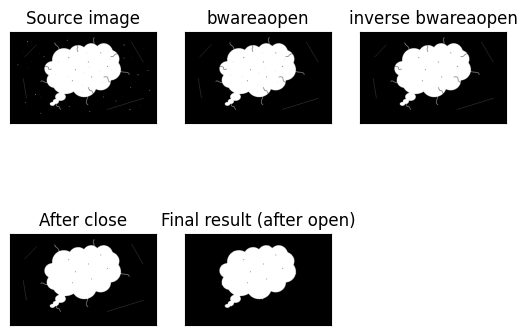

In [27]:
# TODO Place your solution here
fn2own = "images/our_photo.png"
I2own = cv.imread(fn2own, cv.IMREAD_GRAYSCALE)
if not isinstance(I2own, np.ndarray) or I2own.data == None:
  print("Error reading file \"{}\"".format(fn2own))
else:
  # Threshold it
  ret, I2own = cv.threshold(I2own, 127, 255, cv.THRESH_BINARY_INV)
  
  I2clean1 = bwareaopen(I2own, 30)
  
  I2clean2 = ~bwareaopen(~I2clean1, 25)

  element = cv2.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
  
  I2clean3 = cv.morphologyEx(I2clean2, cv.MORPH_CLOSE, element, iterations = 3)
  
  I2clean4 = cv.morphologyEx(I2clean3, cv.MORPH_OPEN, element, iterations = 3)
  
  # Display it
  ShowImages([("Source image", I2own),
              ("bwareaopen", I2clean1),
              ("inverse bwareaopen", I2clean2),
              ("After close", I2clean3),
              ("Final result (after open)", I2clean4)], 3)


## **Task 2. Objects splitting**

*Select an arbitrary binary image containing overlapping objects. Use binary morphology operations to separate objects.*

## **Задание 2. Разделение объектов**

*Выберите произвольное бинарное изображение, содержащее перекрывающиеся объекты. Используйте операции бинарной морфологии, чтобы разделить объекты.*

One of the examples of using morphological operations on an image is the problem of on an image separating objects glued together. The problem can be solved with a sufficient degree of accuracy by sequentially executing the erosion filter several times, and then dilate the result. Intersection of the original image with the processed one will separate the glued objects.

Одним из примеров использования морфологических операций на изображении является задача разделения слипшихся объектов. Эта задача может быть решена с достаточной степенью точности путём последовательного многократного применения фильтра эрозии, а затем дилатации полученного результата. Пересечение исходного изображения с обработанным позволит разделить слипшиеся объекты.

### **2.1 Example**

Let's try implementing this algorithm.

### **2.1 Пример**

Давайте попробуем реализовать этот алгоритм.

#### **2.1.1 Read and preprocess an image**

First of all we need some input image. It's not so interesting to start working with morphology directly, so we will take some image with objects, threshold it to get a binary image, clean it up and use this cleaned up morphology as a starting point. For this we will use an image with some coins on a white table. 

Now we have get a morphology from it. For this we will first convert it to grayscale and threshold the grayscale image.

#### **2.1.1 Чтение и предварительная обработка изображения**

Прежде всего нам нужно какое-либо входное изображение. Начинать работу с морфологией напрямую не так интересно, поэтому мы возьмём изображение с объектами, применим пороговую обработку, чтобы получить бинарное изображение, очистим его и используем эту очищенную морфологию в качестве отправной точки. Для этого мы используем изображение с монетами на белом столе.

Теперь получим из него морфологию. Для этого сначала преобразуем его в градации серого, а затем выполним пороговую обработку полученного полутонового изображения.

In [ ]:
# Read a binary image from file in grayscale
fn2 = "images/coins.jpg"
I2 = cv.imread(fn2, cv.IMREAD_COLOR)
if not isinstance(I2, np.ndarray) or I2.data == None:
  print("Error reading file \"{}\"".format(fn2))
else:
  # Convert it to gayscale
  I2gray = cv.cvtColor(I2, cv.COLOR_BGR2GRAY)
  # Threshold it
  ret, I2bw = cv.threshold(I2gray, 127, 255, cv.THRESH_BINARY_INV)
  # Display these three images
  ShowImages([("Source in BGR", I2),
              ("Grayscale", I2gray)], 2)
  ShowImages([("Morphology", I2bw)], 2)

As you see, the initial morphology to work with is not good with default settings. So we should adjust the thresholding parameters. However in this case we can use another thresholding method which is called Otsu thresholding and invert its result

Как вы видите, исходная морфология для работы с настройками по умолчанию не очень хороша. Поэтому нам следует настроить параметры пороговой обработки. Однако в этом случае мы можем использовать другой метод пороговой обработки, который называется методом Оцу, и инвертировать его результат.

In [ ]:
# Threshold an image
ret, I2m = cv.threshold(I2gray, 127, 255, cv.THRESH_OTSU)
I2m = ~I2m
ShowImages([("Morphology", I2m)], 2)

#### **2.1.2 Clean up the image**

Now we got a morphology we can work with. Let's clean it, we know how to do it already. Most of defects can be cleaned by inverse bwareaopen operations. Other can be cleaned by applying the closing operation.

#### **2.1.2 Очистка изображения**

Теперь у нас есть морфология, с которой можно работать. Давайте очистим её, мы уже знаем, как это сделать. Большинство дефектов можно удалить с помощью инвертированной операции `bwareaopen`. Остальные можно очистить, применив операцию замыкания (`close`).

In [ ]:
# Fill holes
I2clean1 = ~bwareaopen(~I2m, 150)
# Create structuring element
element3x3 = cv2.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
# Close several times to finish cleaning
I2clean2 = cv.morphologyEx(I2clean1, cv.MORPH_CLOSE, element3x3, iterations = 2)
ShowImages([("bwareaopen(150px)", I2clean1), 
            ("Close 2 iterations", I2clean2)], 2)
I2clean = I2clean2

#### **2.1.3 Split objects with erosion**

Now we got a clean morphology, but it still has several objects glued together, so we have to separate them. Let's erode it several times with $7 \times 7$ element. This will give us small separate objects in the centers of objects we are searching for. If we invert the result we will get a shape of the border between objects.

#### **2.1.3 Разделение объектов с помощью эрозии**

Теперь у нас есть очищенная морфология, но в ней всё еще есть несколько слипшихся объектов, поэтому нам нужно их разделить. Давайте несколько раз применим к ней эрозию с элементом размером $7 \times 7$. Это даст нам маленькие отдельные объекты в центрах тех объектов, которые мы ищем. Если инвертировать результат, мы получим форму границы между объектами.

In [ ]:
# Create structuring element
element7x7 = cv2.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
I2centers = cv.morphologyEx(I2clean, cv.MORPH_ERODE, element7x7, iterations = 9, borderType = cv.BORDER_CONSTANT, borderValue = (0))
I2border = ~I2centers
ShowImages([("Erode 9 iterations", I2centers),
            ("Border", I2border)], 2)


#### **2.1.4 Find borders**

As you see, we can't use these borders directly, we have to thicken them. For this need we will use the following algorithm:
 1. Erode the image;
 2. Open the erosion result;
 3. Subtract the erosion result from opening of the erosion;
 4. Add the subtraction result to a thickened borders accumulated;
 5. If there are still any non-zero pixels in the image *go to sep 1*.

 The main idea of this algorithm is that after each erosion we check if the line disappeared in some point by comparing it with opening result. If yes, then we add these pixels to the thickened border. We can adjust this algorithm by using different structuring elements at erosion and opening operations.

 #### **2.1.4 Поиск границ**

Как вы видите, мы не можем использовать эти границы напрямую — их нужно утолщить. Для этого применим следующий алгоритм:

1. Выполнить эрозию изображения;
2. Выполнить размыкание (open) результата эрозии;
3. Вычесть результат эрозии из результата размыкания эрозии;
4. Добавить результат вычитания к накопленным утолщённым границам;
5. Если в изображении всё ещё есть ненулевые пиксели, перейти к шагу 1.

Основная идея этого алгоритма заключается в том, что после каждой эрозии мы проверяем, не исчезла ли линия в какой-то точке, сравнивая её с результатом размыкания. Если да, то мы добавляем эти пиксели к утолщённой границе. Мы можем настраивать этот алгоритм, используя различные структурные элементы для операций эрозии и размыкания.

In [ ]:
element3x3 = cv2.getStructuringElement(cv.MORPH_RECT, (3, 3))
element5x5 = cv2.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
I2tmp = I2border.copy()
I2border2 = np.zeros_like(I2tmp)
while cv.countNonZero(I2tmp) > 0:
  # Dilate
  I2tmp_erode = cv.erode(I2tmp, element3x3, borderType = cv.BORDER_CONSTANT, borderValue = (255))
  # Closing on dilated image
  I2tmp_open = cv.morphologyEx(I2tmp_erode, cv.MORPH_OPEN, element5x5, borderType = cv.BORDER_CONSTANT, borderValue = (0))
  # Subtract them as masks
  subset = cv.bitwise_and(~I2tmp_open, I2tmp_erode)
  # Unite subtraction results with all previous sets
  I2border2 = cv.bitwise_or(subset, I2border2)
  # Continue working with dilated image at next iteration
  I2tmp = I2tmp_erode
# The border is a result of the binary operations, so hold 0 or 1 values
# We multiply it by 255 to get into image range
ShowImages([("Thick border", I2border), ("Thin border", I2border2)], 2)

#### **2.1.5 Process the result**

Now we have thin borders and we can subtract these borders from out morphology and split objects.

#### **2.1.5 Обработка результата**

Теперь у нас есть тонкие границы, и мы можем вычесть эти границы из нашей морфологии, чтобы разделить объекты.

In [ ]:
I2m_split = cv.bitwise_and(I2clean, ~I2border2)
ShowImages([("Result", I2m_split)], vmin = 0, vmax = 255)

Now we can apply this mask to our source image and get split objects.

Теперь мы можем применить эту маску к нашему исходному изображению и получить разделённые объекты.

In [ ]:
I2split = I2.copy()
I2split[I2m_split < 128] = 0
ShowImages([("Source", I2), 
            ("Source morphology", I2m),
            ("Separated", I2split), 
            ("Separated morphology", I2m_split)], 2)

As you can see this method result is not perfect, so we will use another one to get better object separation results.

Как вы можете видеть, результат этого метода не идеален, поэтому мы воспользуемся другим, чтобы добиться лучшего разделения объектов.

### **2.2 Self-work**
### **2.2 Самостоятельная работа**

> ***Self-work***
>
> - *Select an arbitrary binary image containing overlapping objects. Use binary morphology operations to separate objects.*
>
> ***Note:*** 
> 1. *You can use any binary image you like or create your own one by thresholding a grayscale image.*
> 2. *You may start with object morphology image and do steps 2.1.3 - 2.1.5 only.*
> 3. *You are not allowed to use the same image as in the current task guidelines.*
> 4. *You can use any combination of morphological operations to achieve the best result.*
> 5. *You might have to modify the operations order and their parameters to achieve the best result.*
> 6. *You have to show the source image and the split up result image.*
> 7. *You may need to change the `cv2.THRESH_BINARY_INV` flag to `cv2.THRESH_BINARY` in the thresholding step depending on your source image.*
>
> ***Optional:***
> - *Start with objects image and do all steps.*

> ***Самостоятельная работа***
>
> - *Выберите произвольное бинарное изображение, содержащее перекрывающиеся объекты. Используйте операции бинарной морфологии для разделения объектов.*
>
> ***Примечание:*** 
> 1. *Вы можете использовать любое бинарное изображение или создать своё, выполнив пороговую обработку полутонового изображения.*
> 2. *Вы можете начать с изображения морфологии объектов и выполнить только шаги 2.1.3 – 2.1.5.*
> 3. *Вам нельзя использовать то же изображение, что и в текущем задании.*
> 4. *Вы можете использовать любую комбинацию морфологических операций для достижения наилучшего результата.*
> 5. *Возможно, вам придётся изменить порядок операций и их параметры для достижения наилучшего результата.*
> 6. *Вы должны показать исходное изображение и результат разделения.*
> 7. *В зависимости от вашего исходного изображения вам может потребоваться заменить флаг `cv2.THRESH_BINARY_INV` на `cv2.THRESH_BINARY` на этапе пороговой обработки.*
>
> ***Дополнительно:***
> - *Начните с изображения объектов и выполните все шаги.*


In [ ]:
# TODO Place your solution here
I2own = None

## **Task 3. Morphological watershed segmentation**

*Select an arbitrary image containing a small number of local minima. Perform image segmentation by watershed approach.*

## **Задание 3. Морфологическая сегментация методом водораздела**

*Выберите произвольное изображение, содержащее небольшое количество локальных минимумов. Выполните сегментацию изображения с помощью метода водораздела.*

Let us consider one more example of the mathematical morphology application to the image segmentation problem. In the watershed segmentation approach, an image is viewed as a height map, in which pixel intensities describe heights relative to a certain level. On such a "altitude area" is "pouring rain", forming a multitude of *drainage basins*. Water in overflowing basins merge basins into larger ones (see the figure below).

| ![Watershed areas](images/watershed.png "Watershed areas") | 
|:--:| 
| *Watershed areas.*
*Области водораздела.*  |


Basin junctions are marked as watershed lines. If the "rain" is stopped early, then the image will be segmented into small areas, and if it is late then into large ones. In this approach, all pixels are divided into three types:
 - *local minima*;
 - *on the slope* (from which the water rolls down to the same local minimum);
 - *local maxima* (from which the water rolls down to more than one minimum).

 When implementing this method, it is necessary to determine the catchment basins and watershed lines by processing local areas and calculating their characteristics. The segmentation algorithm consists of the following steps:
 1. Segmentation function calculation. Typically, a image gradient representation is used for this.
 2. Foreground markers calculation. Typically, it is based on the pixel connectivity of each object.
 3. Background marker calculation. This marker represents non-object pixels.
 4. Segmentation function execution, taking into account the relative position of the foreground and background markers.

As a algorithm result, a mask will be obtained, where the same segments pixels will be marked with the same markers and will form connected areas.

Рассмотрим ещё один пример применения математической морфологии к задаче сегментации изображений. В подходе водораздела (watershed segmentation) изображение рассматривается как карта высот, где интенсивности пикселей описывают высоты относительно некоторого уровня. На такую «высотную область» проливается «дождь», формируя множество *водосборных бассейнов*. Вода в переполняющихся бассейнах сливается, объединяя бассейны в более крупные (см. рисунок ниже).

Границы между бассейнами отмечаются как линии водораздела. Если «дождь» остановить рано, изображение сегментируется на маленькие области, а если поздно — то на большие. В этом подходе все пиксели делятся на три типа:
- *локальные минимумы*;
- *на склоне* (с которых вода стекает к одному и тому же локальному минимуму);
- *локальные максимумы* (с которых вода стекает более чем к одному минимуму).

При реализации этого метода необходимо определить водосборные бассейны и линии водораздела путём обработки локальных областей и вычисления их характеристик. Алгоритм сегментации состоит из следующих шагов:
1. Вычисление функции сегментации. Обычно для этого используется градиентное представление изображения.
2. Вычисление маркеров переднего плана. Обычно это основано на связности пикселей каждого объекта.
3. Вычисление маркеров фона. Этот маркер представляет пиксели, не принадлежащие объектам.
4. Выполнение функции сегментации с учётом относительного расположения маркеров переднего плана и фона.

В результате работы алгоритма будет получена маска, где пиксели одного сегмента будут помечены одинаковыми маркерами и образовывать связные области.

### **3.1 Example**

Let's implement this algorithm step by step.

### **3.1 Пример**

Давайте реализуем этот алгоритм шаг за шагом.

#### **3.1.1 Read and preprocess an image**

We already know how to do it, so let's read an image.

#### **3.1.1 Чтение и предварительная обработка изображения**

Мы уже знаем, как это делать, поэтому давайте просто прочитаем изображение.

In [ ]:
fn3 = "images/oranges.jpg"

# Read an image from file
I3 = cv.imread(fn3, cv.IMREAD_COLOR)
if not isinstance(I3, np.ndarray) or I3.data == None:
  print("Error reading file \"{}\"".format(fn3))
else:
  # Show images
  ShowImages([("Source", I3)])

Convert it to grayscale and get base morphology from it by thresholding. Since background is darker, we have to do thresholding with inverting the result (controlled by the `invert` flag which sets `cv.THRESH_BINARY_INV` thresholding parameter).

Преобразуйте его в градации серого и получите базовую морфологию с помощью пороговой обработки. Поскольку фон темнее, необходимо выполнить пороговую обработку с инвертированием результата (управляется флагом `invert`, который устанавливает параметр пороговой обработки `cv.THRESH_BINARY_INV`).

In [ ]:
# Convert to grayscale and then to BW
I3gray = cv.cvtColor(I3, cv.COLOR_BGR2GRAY)
invert = False
if invert:
  ret, I3bw = cv.threshold(I3gray, 160, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
else:
  ret, I3bw = cv.threshold(I3gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Show images
ShowImages([("Grayscale", I3gray),
            ("Morphology", I3bw)], 2)

#### **3.1.2 Clean up the morphology**

Now we have to clean this morphology a little to detect object centers.

#### **3.1.2 Очистка морфологии**

Теперь нам нужно немного очистить эту морфологию, чтобы обнаружить центры объектов.

In [ ]:
I3bw_clean = ~bwareaopen(~I3bw, 20, 4)
I3bw_clean = bwareaopen(I3bw_clean, 20, 4)
element5x5 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
I3bw_clean = cv.morphologyEx(I3bw_clean, cv.MORPH_CLOSE, element5x5, iterations = 1)
ShowImages([("Cleaned up", I3bw_clean)], 1)

#### **3.1.3 Getting foreground markers**

To find area with foreground markers we can use the Euclidean distance transformation that calculates the distance to the closest zero pixel for each pixel of the image. This transformation is executed by calling OpenCV\`s `cv2.distanceTransform()` function. Then we will threshold it to find each area center marker.

#### **3.1.3 Получение маркеров переднего плана**

Чтобы найти область с маркерами переднего плана, мы можем использовать преобразование евклидова расстояния, которое для каждого пикселя изображения вычисляет расстояние до ближайшего нулевого пикселя. Это преобразование выполняется вызовом функции OpenCV `cv2.distanceTransform()`. Затем мы применим пороговую обработку, чтобы найти маркеры центров каждой области.


In [ ]:
I3dist = cv.distanceTransform(I3bw_clean, cv.DIST_L2, 5)
ret, I3fg = cv.threshold(I3dist, 0.6 * I3dist.max(), 255, 0)
I3fg = (I3fg.astype(np.float32) / I3fg.max() * 255).astype(np.uint8)
ShowImages([("Distance", I3dist.astype(np.float32) / I3dist.max()),
            ("Foreground", I3fg)], 2)

Now we have all the data required to define foreground markers for the watershed algorithm. To define foreground markers we have to set area index for each marker pixel, this can be done with help of the `cv2.connectedComponents()` function. This function will find all connected components locations which are exactly our marker positions.

To visualize markers with different colors we will use the JET coloring scheme which can be applied to our markers by `cv2.applyColorMap()` function with `cv2.COLORMAP_JET` parameter.

Теперь у нас есть все данные, необходимые для определения маркеров переднего плана для алгоритма водораздела. Чтобы определить маркеры переднего плана, мы должны задать индекс области для каждого пикселя-маркера. Это можно сделать с помощью функции `cv2.connectedComponents()`. Эта функция найдет все местоположения связных компонент, которые и будут нашими позициями маркеров.

Для визуализации маркеров разными цветами мы будем использовать цветовую схему JET, которую можно применить к нашим маркерам с помощью функции `cv2.applyColorMap()` с параметром `cv2.COLORMAP_JET`.

In [ ]:
n_markers, I3markers_fg = cv.connectedComponents(I3fg)
ShowImages([("Foreground", I3fg),
            ("Foreground markers", 
             cv.applyColorMap((I3markers_fg.astype(np.float32) * 255 / n_markers).astype(np.uint8), 
                              cv.COLORMAP_JET))], 2)

#### **3.1.4 Getting background marker**

Next, we have to find a background area marker. It can be found by executing the watershed algorithm on the foreground markers data and selecting the resulting areas boundary area as a background area. This solution works well if objects are placed tightly and background area is hard to mark.

#### **3.1.4 Получение маркера фона**

Далее нам нужно найти маркер фоновой области. Его можно найти, выполнив алгоритм водораздела на данных маркеров переднего плана и выбрав граничную область полученных областей в качестве фоновой области. Это решение хорошо работает, когда объекты расположены плотно и фоновую область трудно маркировать.

In [ ]:
# Create a temporary markers array for executing the watershed algorithm
I3markers = I3markers_fg.copy()
I3markers = cv.watershed(I3, I3markers)
# The border area is indexed as -1 in resulting markers
I3markers_bg = np.zeros_like(I3markers_fg)
I3markers_bg[I3markers == -1] = 255
# Show the result of foreground watershed and the background marker
ShowImages([("Foreground watershed", 
             cv.applyColorMap((I3markers.astype(np.float32) * 255 / ret).astype(np.uint8), 
                              cv.COLORMAP_JET)),
            ("Background", I3markers_bg)], 2)

#### **3.1.5 Define the watershed parameters**

Now we have information about foreground and background markers positions. Everything which is not foreground or background is undefined and is subject to be filled with watershed algorithm.
 - We can find the undefined area as everything except for foreground or background markers.
 - Background marker can be merged into foreground by adding one more marker to with number next to the maximum one.

 #### **3.1.5 Определение параметров водораздела**

Теперь у нас есть информация о положении маркеров переднего плана и фона. Всё, что не является передним планом или фоном, является неопределённым и подлежит заполнению алгоритмом водораздела.

- Мы можем найти неопределённую область как всё, кроме маркеров переднего плана и фона.
- Маркер фона можно объединить с передним планом, добавив ещё один маркер с номером, следующим за максимальным.

In [ ]:
# Undefined area (what to fill with watershed)
I3und = ~np.bitwise_or(I3markers_bg > 0, I3markers_fg > 0)

# Background marker is 0, let's make it 1 to define new unknown region
I3markers = I3markers_fg.copy()
# Now, mark the region of unknown with zero
I3markers[I3markers_bg == 255] = I3markers.max() + 1
ShowImages([("Undefined", I3und),
           ("All markers", 
            cv.applyColorMap((I3markers.astype(np.float32) * 255 / ret).astype(np.uint8), 
                             cv.COLORMAP_JET))], 2)


#### **3.1.6 Run watershed algorithm and process the results**

Now we have all markers set and are ready to run the watershed algorithm by calling the `cv2.watershed()` function.

#### **3.1.6 Запуск алгоритма водораздела и обработка результатов**

Теперь у нас установлены все маркеры, и мы готовы запустить алгоритм водораздела с помощью функции `cv2.watershed()`.

In [ ]:
I3markers = cv.watershed(I3, I3markers)

The `I3markers` matrix now holds the segmentation result. Each pixel is now assigned to some segment and boundary has index $-1$. We may use it to highlight the object boundaries with green color.

Матрица `I3markers` теперь содержит результат сегментации. Каждый пиксель теперь принадлежит некоторому сегменту, а граница имеет индекс $-1$. Мы можем использовать это, чтобы выделить границы объектов зелёным цветом.

In [ ]:
I3result = I3.copy()
# Change color of border pixels
I3result[I3markers == -1] = (255, 0, 0)
ShowImages([("Markers after watershed", 
             cv.applyColorMap((I3markers.astype(np.float32) * 255 / (ret + 1)).astype(np.uint8), 
                              cv.COLORMAP_JET)),
            ("Image with borders", I3result)])

As you see, due to a very thin border, the segmentation result is not perfect and border got significantly thicker due to specifics of the algorithm used.

Как вы видите, из-за очень тонкой границы результат сегментации не идеален, а граница стала значительно толще из-за особенностей используемого алгоритма.

### **3.2 Another approach for background marker**

Another approach to find a background area marker can be by sequential dilation of the filtered black and white image. The inversion of dilation result should give us an area that is sure to be a background and can act as a background marker. This solution works well in case if background area is rather big and would not become empty after dilation operation.

Let's try this approach on the coins images we saw in the **Task 2** and stored in `I2` image with morphology in `I2clean`.

### **3.2 Другой подход к получению маркера фона**

Другой подход к поиску маркера фоновой области может заключаться в последовательной дилатации отфильтрованного черно-белого изображения. Инверсия результата дилатации должна дать нам область, которая точно является фоном, и может выступать в качестве маркера фона. Это решение хорошо работает, если фоновая область достаточно велика и не станет пустой после операции дилатации.

Давайте попробуем этот подход на изображениях монет, которые мы видели в **Задании 2** и которые хранятся в изображении `I2` с морфологией в `I2clean`.

**Foreground marker**

First we will repeat same steps to get foreground markers.

**Маркер переднего плана**

Сначала мы повторим те же шаги, чтобы получить маркеры переднего плана.

In [ ]:
# Foreground markers
I2dist = cv.distanceTransform(I2clean, cv.DIST_L2, 5)
ret, I2fg = cv.threshold(I2dist, 0.6 * I2dist.max(), 255, 0)
I2fg = (I2fg.astype(np.float32) / I2fg.max() * 255).astype(np.uint8)
ShowImages([("Distance", I2dist.astype(np.float32) / I2dist.max()),
            ("Foreground", I2fg)], 2)

In [ ]:
n_markers, I2markers_fg = cv.connectedComponents(I2fg)
ShowImages([("Foreground", I2fg),
            ("Foreground markers", 
             cv.applyColorMap((I2markers_fg.astype(np.float32) * 255 / n_markers).astype(np.uint8), 
                              cv.COLORMAP_JET))], 2)

**Background marker**

Background area can be defined by inverse of dilation of the initial morphology.

**Маркер фона**

Фоновую область можно определить как инверсию дилатации исходной морфологии.

In [ ]:
element7x7 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
I2markers_bg = ~cv.morphologyEx(I2clean, cv.MORPH_DILATE, element7x7, iterations = 2)
ShowImages([("Foreground", I2fg),
            ("Background", I2markers_bg)], 2)

**Define parameters**

**Определение параметров**

In [ ]:
# Undefined area (what to fill with watershed)
I2und = ~np.bitwise_or(I2markers_bg > 0, I2markers_fg > 0)

# Background marker is 0, let's make it 1 to define new unknown region
I2markers = I2markers_fg.copy()
# Now, mark the region of unknown with zero
I2markers[I2markers_bg == 255] = I2markers.max() + 1
ShowImages([("Undefined", I2und),
           ("All markers", 
            cv.applyColorMap((I2markers.astype(np.float32) * 255 / ret).astype(np.uint8), 
                             cv.COLORMAP_JET))], 2)


**Run watershed algorithm and process the results**

**Запуск алгоритма водораздела и обработка результатов**

In [ ]:
# Run watershed
I2markers = cv.watershed(I2, I2markers)
I2result = I2.copy()
# Change color of border pixels
I2result[I2markers == -1] = (255, 0, 0)
ShowImages([("Markers after watershed", 
             cv.applyColorMap((I2markers.astype(np.float32) * 255 / (ret + 1)).astype(np.uint8), 
                              cv.COLORMAP_JET)),
            ("Image with borders", I2result)])

### **3.3 Self-work**

### **3.3 Самостоятельная работа**

> ***Self-work***
>
> - *Select an arbitrary image containing a small number of local minima. Perform image segmentation by watershed approach.*
> 
> ***Note:***
> 1. *You are not allowed to use the same image as in the current task guidelines.*
> 2. *You can use any combination of morphological operations to achieve the best result.*
> 3. *You might have to modify the operations order and their parameters to achieve the best result.*
> 4. *You have to show at least the source image, the markers, the segmentation result image and the border between segments.*
> 5. *You may need to change the `cv2.THRESH_BINARY_INV` flag to `cv2.THRESH_BINARY` in the thresholding step depending on your source image.*

> ***Самостоятельная работа***
>
> - *Выберите произвольное изображение, содержащее небольшое количество локальных минимумов. Выполните сегментацию изображения с помощью метода водораздела.*
>
> ***Примечание:***
> 1. *Вам нельзя использовать то же изображение, что и в текущем задании.*
> 2. *Вы можете использовать любую комбинацию морфологических операций для достижения наилучшего результата.*
> 3. *Возможно, вам придётся изменить порядок операций и их параметры для достижения наилучшего результата.*
> 4. *Вы должны показать как минимум исходное изображение, маркеры, результат сегментации и границы между сегментами.*
> 5. *В зависимости от вашего исходного изображения вам может потребоваться заменить флаг `cv2.THRESH_BINARY_INV` на `cv2.THRESH_BINARY` на этапе пороговой обработки.*


In [ ]:
# TODO Place your solution here
I3own = None

 ## **Questions**
 ## **Вопросы**


Please answer the following questions:

Пожалуйста, ответьте на следующие вопросы:

 - Does the opening result include the closing result?
 - Включает ли в себя результат размыкания (opening) результат замыкания (closing)?
 > Нет, это две разные операции, решающие противоположные задачи.
 >
 > Opening удаляет внешние выступы и шум, сглаживая контур объекта.
 >
 > Closing заполняет внутренние дыры и разрывы.
 > 
 > Обычно opening не содержит closing, так как они изменяют форму в разных направлениях: opening сужает форму, closing расширяет.
 >
 
 - What morphological filter should be applied to remove ledges from an object?
 - Какой морфологический фильтр следует применить для удаления выступов (ledges) с объекта?
 > Для удаления внешних выступов (ledges) с объекта следует применить размыкание (opening).
 >
 > Opening — это эрозия, за которой следует дилатация.
 > $open(A, B) = (A \ominus B) \oplus B$ 
 >
 > Сначала эрозия удаляет мелкие выступы и отделяет их от основного объекта, затем дилатация восстанавливает размер объекта, но без удалённых выступов.
 >
 
 - How can you find the object edges using morphological operations?
 - Как можно найти границы объекта с помощью морфологических операций?
 > Вставьте ваш ответ здесь
 >
 
 - What is morphology?
 - Что такое морфология?
 > Вставьте ваш ответ здесь
 >


## **Conclusion**
## **Вывод**

What have you learned with this task? Don't forget to conclude it.
Что вы узнали, выполняя это задание? Не забудьте подвести итог.
 > В ходе выполнения **Задания 1** были изучены основные принципы морфологического анализа бинарных изображений. 

 > Мы научились:
 > - Создавать структурные элементы разных форм (`cv2.getStructuringElement`): прямоугольные, крестообразные, эллиптические.
 > - Применять базовые морфологические операции:
 >   - **Эрозия** (`cv2.MORPH_ERODE`) — сужает объект, удаляет мелкие внешние выступы, но увеличивает внутренние дыры.
 >   - **Дилатация** (`cv2.MORPH_DILATE`) — расширяет объект, заполняет внутренние дыры, но увеличивает внешние шумы.
 >   - **Размыкание (opening)** (`cv2.MORPH_OPEN`) — эрозия + дилатация. Удаляет внешние дефекты (выступы), сохраняя общий размер формы.
 >   - **Замыкание (closing)** (`cv2.MORPH_CLOSE`) — дилатация + эрозия. Удаляет внутренние дефекты (дыры), сохраняя общий размер.
 > - Выделять внутренние и внешние контуры объекта с помощью разности между исходным изображением и результатом эрозии/дилатации.
 > - Реализовать аналог MATLAB-функции `bwareaopen` для удаления мелких связных компонент по площади. 
 > - Применять эту функцию как напрямую (для внешних областей), так и с инверсией (для внутренних дыр).
 > - Комбинировать несколько морфологических операций и итераций для качественной очистки изображения от дефектов.

В итоге мы смогли взять произвольное бинарное изображение с внешними выступами и внутренними дырами и почти полностью удалить или минимизировать эти дефекты, используя подбор структурного элемента и последовательное применение размыкания, замыкания и `bwareaopen`.

 >
